# Initial configuration

In [46]:
import os
import torch
from pathlib import Path
from matplotlib import font_manager
import matplotlib.pyplot as plt
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# Data Paths 
DATASET_PATH = '../DATA/etlcb/ETL9B'          # ETL9G Dataset (_unpack folders)
PREDICTION_FOLDER = '../TESTS'                       # Folder with images for prediction
CASIA_DATASET_TRAIN_PATH = "../DATA/chinese-handwriting/CASIA-HWDB_Train/Train" # CASIA Dataset Traububg Folder
CASIA_DATASET_TEST_PATH = "../DATA/chinese-handwriting/CASIA-HWDB_Test/Test" # CASIA Dataset Test Folder

# Output Paths
OUTPUT_DIR = './Training_Output'                     # Main output folder

# File Names
MODEL_FILENAME = 'best_kanji_model.pth'              # Trained model
HISTORY_FILENAME = 'training_history.json'           # Training history
CLASSES_FILENAME = 'classes.json'                    # Class mapping

# Full File Paths 
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, MODEL_FILENAME)
HISTORY_SAVE_PATH = os.path.join(OUTPUT_DIR, HISTORY_FILENAME)
CLASSES_SAVE_PATH = os.path.join(OUTPUT_DIR, CLASSES_FILENAME)
MODEL_PATH = MODEL_SAVE_PATH  # Alias for prediction scripts

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Fonts 
FONT_PATH = "../Noto_Sans_JP/static/NotoSansJP-Regular.ttf"

def load_font():
    font_path = Path(FONT_PATH)

    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        print("Font loaded.")
    else:
        print(f"WARNING: Font not found at {font_path}.")

# Hyperparameters
BATCH_SIZE = 128         
LEARNING_RATE = 0.0002
NUM_EPOCHS = 30
IMG_SIZE = 128

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configuration loaded")
print(f"   • Dataset: {DATASET_PATH}")
print(f"   • Output: {OUTPUT_DIR}")
print(f"   • Model: {MODEL_SAVE_PATH}")

Using device: cuda
Paths configuration loaded
   • Dataset: ../DATA/etlcb/ETL9B
   • Output: ./Training_Output
   • Model: ./Training_Output/best_kanji_model.pth


# Dataset and model setup

In [47]:
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm 
import matplotlib.pyplot as plt
import json
import pandas as pd
from PIL import Image
import os 

MAX_CLASSES_LIMIT = 150
print(f"Indexing full dataset (Limit: {MAX_CLASSES_LIMIT})...")
    
class GaussianNoise(object):
    # Adds random noise to the image to improve model robustness
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

class MorphologicalTransform(object):
    """Aplica randomly Erode or Dilate operations"""
    def __init__(self, kernel_size=3, p=0.5):
        self.kernel_size = kernel_size
        self.p = p
        self.kernel = np.ones((kernel_size, kernel_size), np.uint8)
    
    def __call__(self, img):
        img_np = np.array(img)
        
        if np.random.random() < self.p:
            operation = np.random.choice(['erode', 'dilate'])
            if operation == 'erode':
                img_np = cv2.erode(img_np, self.kernel, iterations=1)
            else:
                img_np = cv2.dilate(img_np, self.kernel, iterations=1)
        return Image.fromarray(img_np)

# Custom Dataset Class
class ETL9Dataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, max_classes=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = [] 
        
        subfolders = sorted([f for f in os.listdir(root_dir) if f.endswith('_unpack')])
        
        if not subfolders:
            print(f"WARNING: No '_unpack' folders found in {root_dir}")
        
        # Getting only the number of selected classes
        if max_classes is not None:
            all_classes = set()
            
            for folder in subfolders:
                folder_path = os.path.join(root_dir, folder)
                csv_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
                
                if csv_files:
                    csv_path = os.path.join(folder_path, csv_files[0])
                    try:
                        df = pd.read_csv(csv_path)
                        for label_char in df.iloc[:, 1]:
                            # Kanji based on Unicode range
                            if '\u4e00' <= label_char <= '\u9fff':
                                all_classes.add(label_char)
                    except Exception as e:
                        print(f"Error while reading {csv_path}: {e}")
            
            # Select the first max_classes
            all_classes_sorted = sorted(list(all_classes))
            selected_classes = set(all_classes_sorted[:max_classes])
        else:
            selected_classes = None
        
        # Load only images from that classes
        for folder in subfolders:
            folder_path = os.path.join(root_dir, folder)
            csv_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
            
            if csv_files:
                csv_path = os.path.join(folder_path, csv_files[0])
                try:
                    df = pd.read_csv(csv_path)
                    for _, row in df.iterrows():
                        label_char = row.iloc[1]
                        
                        # Kanji based on Unicode range
                        if '\u4e00' <= label_char <= '\u9fff':
                            if selected_classes is None or label_char in selected_classes:
                                img_name = f"{int(row.iloc[0]):05d}.png"
                                img_path = os.path.join(folder_path, img_name)
                                
                                if os.path.exists(img_path):
                                    self.samples.append((img_path, label_char))
                                    
                except Exception as e:
                    print(f"Error reading {csv_path}: {e}")
        
        self.classes = sorted(list(set([x[1] for x in self.samples])))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        print(f"Dataset initialized. Images: {len(self.samples)}. Classes (Kanji): {len(self.classes)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_char = self.samples[idx]
        image = Image.open(img_path).convert('L')
        label_idx = self.class_to_idx[label_char]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label_idx)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Data Augmentation and Transforms
train_transforms = transforms.Compose([ 
    transforms.Resize((IMG_SIZE, IMG_SIZE)), 
    transforms.Grayscale(num_output_channels=3), # ResNet requires 3 channels, so we replicate the grayscale channel
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3), 
    transforms.RandomAffine( 
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.ElasticTransform(alpha=50.0, sigma=5.0),     
    transforms.ColorJitter(brightness=0.3, contrast=0.3),   
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)), 
    MorphologicalTransform(kernel_size=3, p=0.5),
    transforms.ToTensor(),
    GaussianNoise(0., 0.03), 
    transforms.RandomErasing(p=0.3), 
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([ 
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load and Index Dataset
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Root directory not found at: {DATASET_PATH}")

print("Indexing full dataset...")
# Aquí aplicamos el límite definido al inicio de la celda
full_dataset = ETL9Dataset(root_dir=DATASET_PATH, transform=None, max_classes=MAX_CLASSES_LIMIT)

if len(full_dataset) == 0:
    raise ValueError("Dataset is empty. Check path and unpacked folders.")

# Split dataset into Train, Validation, and Test
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size
print(f"Total: {total_size}")
print(f"Split: Train={train_size}, Val={val_size}, Test={test_size}")


# Create random indices for splitting
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total_size, generator=generator).tolist()
train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

print("Preparing subsets...")
train_dataset_augmented = ETL9Dataset(root_dir=DATASET_PATH, transform=train_transforms, max_classes=MAX_CLASSES_LIMIT)
base_dataset = ETL9Dataset(root_dir=DATASET_PATH, transform=val_transforms, max_classes=MAX_CLASSES_LIMIT)

train_subset = Subset(train_dataset_augmented, train_idx)
val_subset = Subset(base_dataset, val_idx)
test_subset = Subset(base_dataset, test_idx)

# Initialize DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready")

# Model Setup
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
input_features = model.fc.in_features 
num_classes = len(full_dataset.classes) 

model.fc = nn.Linear(input_features, num_classes) # Adapting last layer
model = model.to(device)
print(f"{type(model).__name__} configured for {num_classes} classes.")

Indexing full dataset (Limit: 150)...
Using device: cuda
Indexing full dataset...
Dataset initialized. Images: 30150. Classes (Kanji): 150
Total: 30150
Split: Train=24120, Val=3015, Test=3015
Preparing subsets...
Dataset initialized. Images: 30150. Classes (Kanji): 150
Dataset initialized. Images: 30150. Classes (Kanji): 150
DataLoaders ready
ResNet configured for 150 classes.


# Model training

In [48]:
import json

# Main training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_acc = 0.0
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    print(f"Saving results to: {OUTPUT_DIR}")
    
    for epoch in range(num_epochs): 
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training Phase
        model.train() # Set model to training mode (enables Dropout/BatchNorm)
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # Clear gradients from previous step
            
            # Forward pass: Compute predicted outputs by passing inputs to the model
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
        
            loss = criterion(outputs, labels) # Calculate loss
        
            loss.backward() # Compute gradients
            
            optimizer.step() # Updates network weights based on gradients

            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Training stats
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double().item() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Validation
        model.eval() # Set model to evaluation mode 
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        # Validation stats
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double().item() / len(val_loader.dataset)
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH) 
            print(f"Model saved: {MODEL_SAVE_PATH}")

    print('\nTraining finished.')
    return model, history

# Execution 
criterion = nn.CrossEntropyLoss() # Loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

# Save history and classes
with open(HISTORY_SAVE_PATH, 'w') as f:
    json.dump(history, f)
print(f"History saved to: {HISTORY_SAVE_PATH}")

with open(CLASSES_SAVE_PATH, 'w') as f:
    json.dump(full_dataset.classes, f, ensure_ascii=False)  
print(f"Classes saved to: {CLASSES_SAVE_PATH}")

Saving results to: ./Training_Output

Epoch 1/30
----------


Training: 100%|██████████| 189/189 [06:47<00:00,  2.15s/it]

Train Loss: 1.5588 Acc: 0.7164


Val Loss: 1.4756 Acc: 0.6282
Model saved: ./Training_Output/best_kanji_model.pth

Epoch 2/30
----------


Training: 100%|██████████| 189/189 [06:35<00:00,  2.09s/it]

...

Train Loss: 0.0460 Acc: 0.9857


Val Loss: 0.1005 Acc: 0.9648

Epoch 30/30
----------


Training: 100%|██████████| 189/189 [06:33<00:00,  2.08s/it]

Train Loss: 0.0459 Acc: 0.9852


Val Loss: 0.0962 Acc: 0.9721

Training finished.
History saved to: ./Training_Output/training_history.json
Classes saved to: ./Training_Output/classes.json


# Training metrics

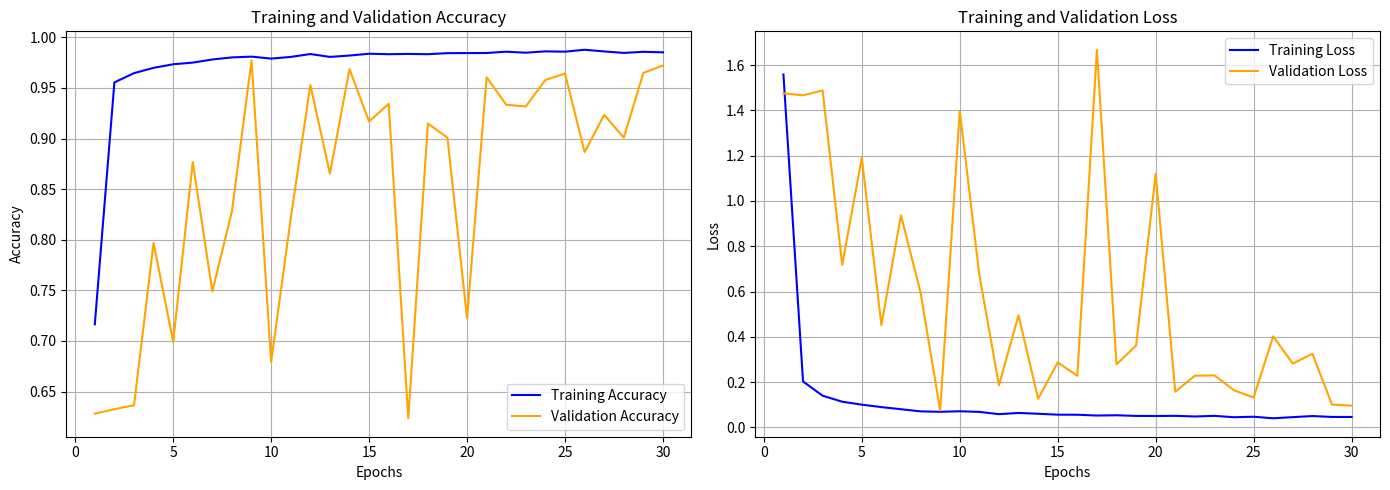

In [49]:
import json
import matplotlib.pyplot as plt

def plot_training_history():
    with open(HISTORY_SAVE_PATH, 'r') as f:
        history = json.load(f)
    
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
plot_training_history()

# Test evaluation

Font loaded.
Classes loaded from ./Training_Output/classes.json (150 classes).
Analyzing Test data...


Processing: 100%|██████████| 24/24 [00:02<00:00,  9.06it/s]


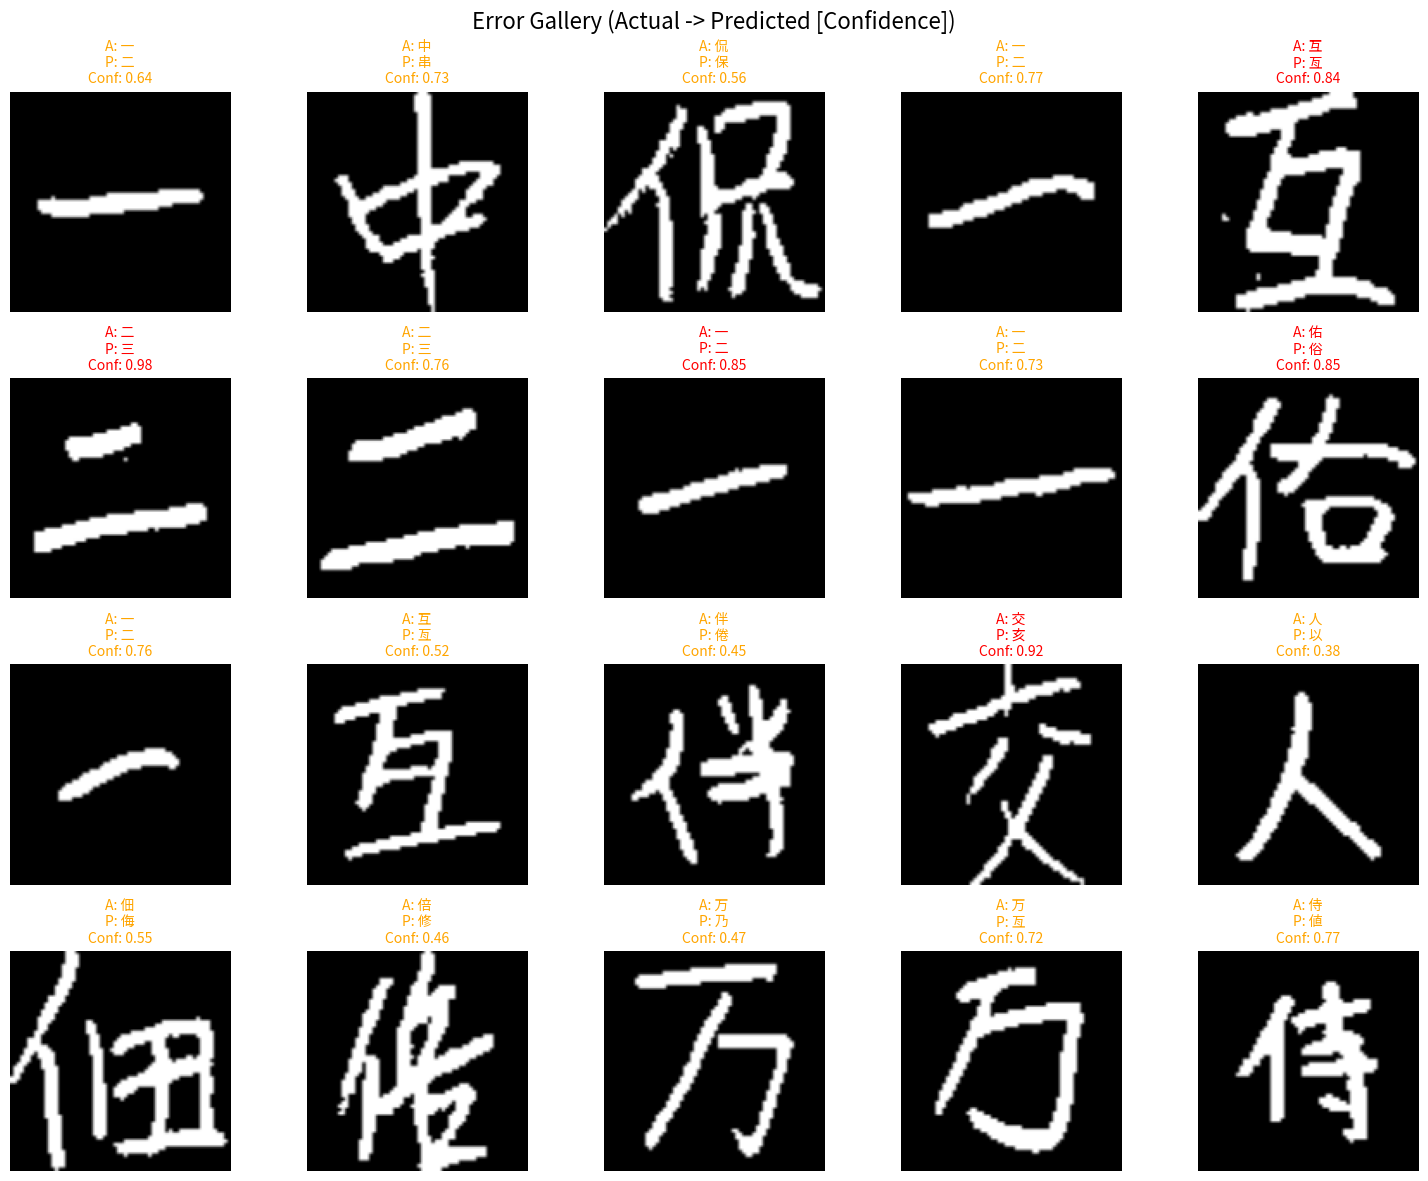


--- TOP KANJIS WITH MOST ERRORS ---
Actual
一    19
二    14
万     6
互     5
仕     4
中     3
仲     3
倍     3
九     2
伏     2
Name: count, dtype: int64

--- MOST COMMON CONFUSIONS (Actual -> Predicted) ---
Actual  Predicted
一       二            19
二       三            14
互       亙             5
万       乃             3
仲       伸             3
万       丙             2
九       仇             2
何       伺             2
倍       信             2
且       亘             1
dtype: int64

Global Test Accuracy: 97.01%


In [50]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
from tqdm import tqdm
import json

# Loading a displayable japanese font
load_font()

# Function to display some tests
def visualize_errors_and_metrics(model, test_loader, class_names):
    model.eval() # Set model to evaluation mode
    all_preds = []
    all_labels = []
    mistakes = [] 
    MISTAKES_TO_DISPLAY = 20
    ROWS = 4
    COLUMNS = 5
    
    print("Analyzing Test data...")
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Processing"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            wrong_indices = (preds != labels).nonzero()
            for idx in wrong_indices:
                idx = idx.item()
                if len(mistakes) < MISTAKES_TO_DISPLAY: # Just displaying limited mistakes
                    img = inputs[idx].cpu()
                    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                    img = img * std + mean
                    img = torch.clamp(img, 0, 1)
                    
                    mistakes.append({
                        'img': img,
                        'pred_lbl': class_names[preds[idx].item()],
                        'true_lbl': class_names[labels[idx].item()],
                        'conf': conf[idx].item()
                    })

    # Displaying mistakes
    if len(mistakes) > 0:
        fig, axes = plt.subplots(ROWS, COLUMNS, figsize=(15, 12))
        fig.suptitle('Error Gallery (Actual -> Predicted [Confidence])', fontsize=16)
        axes = axes.flatten()
        
        for i, ax in enumerate(axes):
            if i < len(mistakes):
                m = mistakes[i]
                img_np = m['img'].permute(1, 2, 0).numpy()
                ax.imshow(img_np)
                
                color = 'red' if m['conf'] > 0.8 else 'orange'
                ax.set_title(f"A: {m['true_lbl']}\nP: {m['pred_lbl']}\nConf: {m['conf']:.2f}", 
                             color=color, fontsize=10, fontweight='bold')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No errors found in the visualized sample.")

    # Stats
    df = pd.DataFrame({
        'Actual': [class_names[i] for i in all_labels],
        'Predicted': [class_names[i] for i in all_preds]
    })
    
    errors_df = df[df['Actual'] != df['Predicted']]
    
    if not errors_df.empty:
        print("\n--- TOP KANJIS WITH MOST ERRORS ---")
        print(errors_df['Actual'].value_counts().head(10))
        
        print("\n--- MOST COMMON CONFUSIONS (Actual -> Predicted) ---")
        print(errors_df.groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(10))
    
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nGlobal Test Accuracy: {acc*100:.2f}%")

# Execution
try:
    with open(CLASSES_SAVE_PATH, 'r') as f:
        class_names = json.load(f)
    print(f"Classes loaded from {CLASSES_SAVE_PATH} ({len(class_names)} classes).")
except FileNotFoundError:
    print(f"File not found {CLASSES_SAVE_PATH}. Using global variable 'full_dataset'...")
    class_names = full_dataset.classes

model = model.to(device)
visualize_errors_and_metrics(model, test_loader, class_names)

# Evaluation with samples that aren't in the dataset

Font loaded.


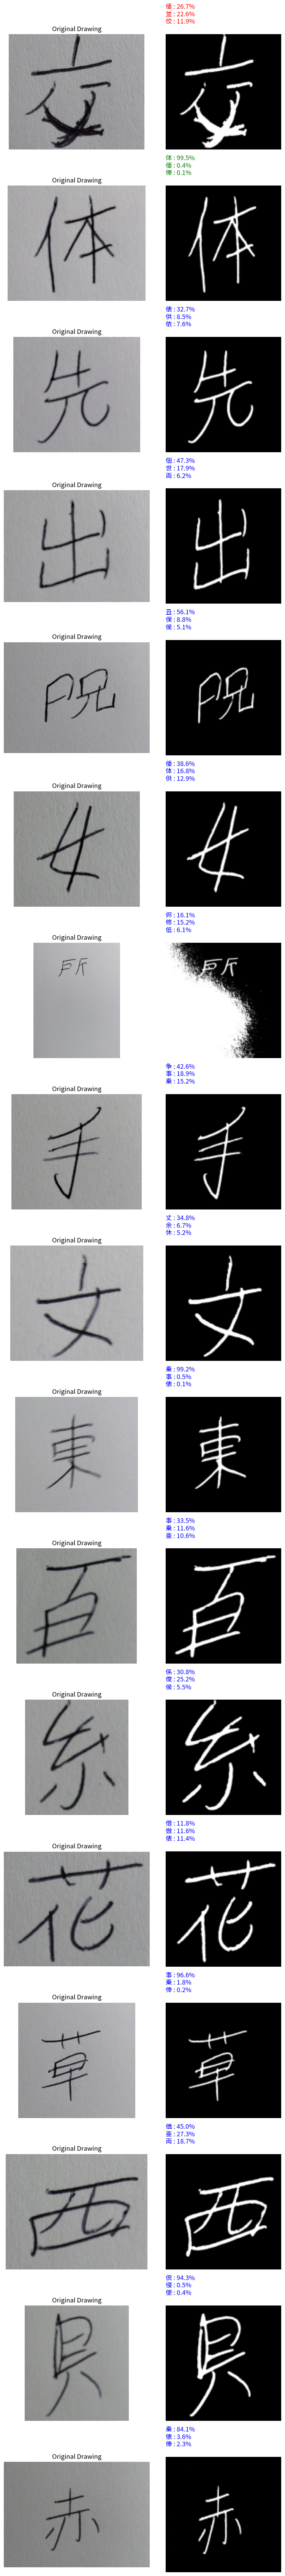

--- Predictions Results (2 images) ---
Top-1 Accuracy: 1/2 (50.00%)
Top-3 Accuracy: 1/2 (50.00%)
Top-5 Accuracy: 1/2 (50.00%)


In [51]:
import cv2
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from matplotlib import font_manager

# Loading a displayable japanese font
load_font()

# Load class names
with open(CLASSES_SAVE_PATH, 'r') as f:
    class_names = json.load(f)
num_classes = len(class_names)
set_classes = set(class_names)

# Define inference transformations
inference_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def binarize(img):
    img_array = np.array(img)
    _, img_array = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(img_array)


def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    
    # Detecting if the background is more black or white
    img_array = np.array(img)
    mean_intensity = img_array.mean()
    
    if mean_intensity > 127.5:  # White background --> Invert
        img = ImageOps.invert(img)
    
    # Binarizar
    img = binarize(img)
    
    # Resize y convertir a RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = img.convert('RGB')
    return img

def denormalize(tensor):
    # Reverts normalization to display the image correctly
    img = tensor.clone().detach().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

# Model setup
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, num_classes) # Adjust final layer
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device)) # Load weights
model = model.to(device)
model.eval() # Set to evaluation mode

def predict_and_evaluate(folder_path, skip_not_in_classes = False, display = True):
    """Make inferences and show stats with the directory passed as parameter.
    Current admited formats:
        - "class_name.jpg/png/jpeg"
        - "class_name/2332.jpg/png/jpeg"
    Parameters:
        - skip_not_in_classes: If true, images which classes aren't contained in the model's classes are skipped
        - display: If true, display a plot of the image, the binarized image and top 3 predictions
    """

    # Scan directory for images
    files = [os.path.join(root, f) 
         for root, dirs, files in os.walk(folder_path) 
         for f in files 
         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    # print(files) Es una lista de rutas.
    if not files: 
        print("No images found in the folder.")
        return

    if skip_not_in_classes: # Skipping images which class is not contained in the classes of the dataset
        valid_files = []
        for file_name in files:
            # Getting class from filename
            ground_truth = file_name.split("/")[-1][0] 
            if ground_truth.isdigit():
                ground_truth = file_name.split("/")[-2][0] # Getting parent folder name as classs
            if ground_truth in class_names: valid_files.append(file_name)
        files = valid_files

    top1_correct = 0
    top3_correct = 0
    top5_correct = 0
    total_evaluated = 0

    rows = len(files)
    if display:
        fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(8, 4 * rows))
    if rows == 1: axes = [axes] # Handle single image case

    for i, file_name in enumerate(files):

        # Getting class from filename
        ground_truth = file_name.split("/")[-1][0] 
        if ground_truth.isdigit():
            ground_truth = file_name.split("/")[-2][0] # Getting parent folder name as classs
        file_path = file_name
        
        # Load and preprocess
        original_img_show = Image.open(file_path)
        prepared_img_pil = preprocess_image(file_path)
        img_tensor = inference_transforms(prepared_img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            top5_prob, top5_idx = torch.topk(probs, 5)
            top5_indexes = top5_idx[0].cpu().numpy()
            top5_classes = [class_names[idx] for idx in top5_indexes]
            
            # Text color logic and counting
            title_color = 'blue' 
            if ground_truth in set_classes:
                total_evaluated += 1
                # Check Top 1 
                if ground_truth == top5_classes[0]:
                    top1_correct += 1
                    title_color = 'green' # Mejor color para acierto perfecto
                # Check Top 3 
                if ground_truth in top5_classes[:3]:
                    top3_correct += 1
                    if title_color != 'green': title_color = 'yellow' # Casi
                # Check Top 5
                if ground_truth in top5_classes:
                    top5_correct += 1
                    if title_color not in ['green', 'yellow']: title_color = 'orange' # Por los pelos
                
                # Si no está en ninguno
                if ground_truth not in top5_classes:
                    title_color = 'red' 

        if not display: continue # Skip if not displaying

        # Plot original image
        axes[i][0].imshow(original_img_show)
        axes[i][0].set_title("Original Drawing")
        axes[i][0].axis('off')

        # Plot the replication of what model sees
        visible_tensor = denormalize(img_tensor.squeeze(0))
        axes[i][1].imshow(visible_tensor)
        
        # Format results text
        res_txt = ""
        top3_p = top5_prob[0][:3].cpu().numpy()
        top3_i = top5_indexes[:3]
        for idx, p in zip(top3_i, top3_p):
            res_txt += f"{class_names[idx]} : {p*100:.1f}%\n"
            
        axes[i][1].set_title(res_txt, color=title_color, loc='left')
        axes[i][1].axis('off')

    if display:
        plt.tight_layout()
        plt.show()
    
    # Print accuracy stats
    if total_evaluated > 0:
        print(f"--- Predictions Results ({total_evaluated} images) ---")
        print(f"Top-1 Accuracy: {top1_correct}/{total_evaluated} ({top1_correct/total_evaluated*100:.2f}%)")
        print(f"Top-3 Accuracy: {top3_correct}/{total_evaluated} ({top3_correct/total_evaluated*100:.2f}%)")
        print(f"Top-5 Accuracy: {top5_correct}/{total_evaluated} ({top5_correct/total_evaluated*100:.2f}%)")
    else:
        print("Accuracy not evaluated (filenames do not match known classes)")

# Execution
predict_and_evaluate(PREDICTION_FOLDER, skip_not_in_classes=False, display=True)

# Evaluation with other dataset (CASIA training set)

In [52]:
print("====== Evaluation with CASIA train set ======")
predict_and_evaluate(CASIA_DATASET_TRAIN_PATH, skip_not_in_classes=True, display=False)
print("====== Evaluation with CASIA test set ======")
predict_and_evaluate(CASIA_DATASET_TEST_PATH, skip_not_in_classes=True, display=False)

====== Evaluation with CASIA train set ======
--- Predictions Results (13163 images) ---
Top-1 Accuracy: 8324/13163 (63.24%)
Top-3 Accuracy: 10866/13163 (82.55%)
Top-5 Accuracy: 11539/13163 (87.66%)
====== Evaluation with CASIA test set ======
--- Predictions Results (3148 images) ---
Top-1 Accuracy: 2230/3148 (70.84%)
Top-3 Accuracy: 2752/3148 (87.42%)
Top-5 Accuracy: 2866/3148 (91.04%)
